# Part 1 – Neural Network Fundamentals and Training Behavior Analysis

| | |
|---|---|
| **Dataset** | `customer_churn_nn.csv` – 2 000 customers, 17 columns |
| **Target** | `churn` (1 = churned, 0 = retained) |
| **Python** | 3.12 |
| **Framework** | TensorFlow / Keras |

**Notebook structure**
1. Dataset Understanding  
2. Data Preprocessing  
3. Neural Network Model Building  
4. Training and Evaluation  
5. Hyperparameter Experimentation  
6. Final Reflection


---
## Task 1 – Dataset Understanding

In [3]:
# Uncomment and run once if packages are not yet installed
# !pip install tensorflow==2.16.1 pandas numpy matplotlib seaborn scikit-learn

import os, warnings, time
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

os.makedirs('results', exist_ok=True)


In [4]:
# Load dataset before using it
df = pd.read_csv('customer_churn_nn.csv')

print('Data types and non-null counts:')
df.info()
print()

feature_map = {
    'Identifier' : ['customer_id'],
    'Categorical': ['region', 'plan_type', 'contract_type', 'payment_method'],
    'Binary'     : ['autopay_enabled'],
    'Numerical'  : [
        'tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
        'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
        'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'referral_count'
    ],
    'Target'     : ['churn']
}
for ftype, cols in feature_map.items():
    print(f'  {ftype:12s}: {cols}')

Data types and non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   str    
 1   region                        2000 non-null   str    
 2   plan_type                     2000 non-null   str    
 3   contract_type                 2000 non-null   str    
 4   payment_method                2000 non-null   str    
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-nu

In [5]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'None – dataset is complete.')

Missing values per column:
None – dataset is complete.


In [6]:
print('Statistical summary – numerical columns:')
display(df.describe().round(2))

Statistical summary – numerical columns:


,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.00,2000.00,2000.0,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,25.36,766.49,18.1,1.95,3.56,90.01,6.87,46.62,8.26,0.60,0.92,0.02
std,14.13,393.42,5.4,1.46,3.89,53.22,1.52,55.07,7.55,0.49,1.04,0.12
min,1.00,255.45,0.0,0.00,0.00,0.50,1.00,0.00,0.00,0.00,0.00,0.00
25%,15.00,427.78,15.0,1.00,1.00,51.78,5.88,6.00,0.00,0.00,0.00,0.00
50%,23.00,688.36,18.0,2.00,2.00,80.24,6.80,28.50,5.00,1.00,1.00,0.00
75%,33.00,1007.37,22.0,3.00,5.00,119.10,8.00,68.00,15.00,1.00,1.00,0.00
max,72.00,2156.52,30.0,8.00,31.00,265.51,10.00,424.00,20.00,1.00,7.00,1.00


Target variable – churn:
  0  Retained :  1969  (98.45%)
  1  Churned  :    31  (1.55%)
  Imbalance ratio : 64:1


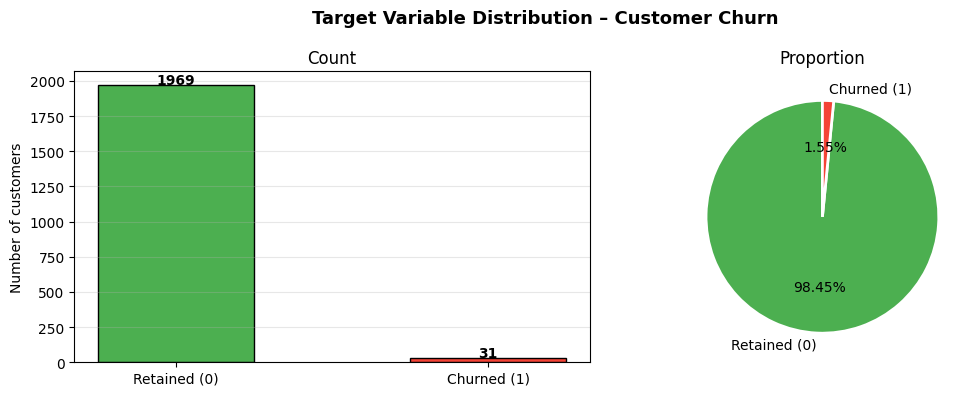

Saved → results/target_distribution.png

Note: 63:1 imbalance – accuracy alone will be misleading. Use ROC-AUC and recall.


In [8]:
counts = df['churn'].value_counts().sort_index()
pcts   = df['churn'].value_counts(normalize=True).sort_index() * 100

print('Target variable – churn:')
print(f'  0  Retained : {counts[0]:>5}  ({pcts[0]:.2f}%)')
print(f'  1  Churned  : {counts[1]:>5}  ({pcts[1]:.2f}%)')
print(f'  Imbalance ratio : {counts[0]/counts[1]:.0f}:1')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Target Variable Distribution – Customer Churn', fontsize=13, fontweight='bold')

bars = axes[0].bar(['Retained (0)', 'Churned (1)'], counts.values,
                   color=['#4CAF50', '#F44336'], edgecolor='black', width=0.5)
for bar, v in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, v + 5,
                 str(v), ha='center', fontweight='bold')
axes[0].set_ylabel('Number of customers')
axes[0].set_title('Count')
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie(counts.values,
            labels=['Retained (0)', 'Churned (1)'],
            autopct='%1.2f%%',
            colors=['#4CAF50', '#F44336'],
            startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proportion')

plt.tight_layout()
plt.savefig('results/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/target_distribution.png')
print('\nNote: 63:1 imbalance – accuracy alone will be misleading. Use ROC-AUC and recall.')

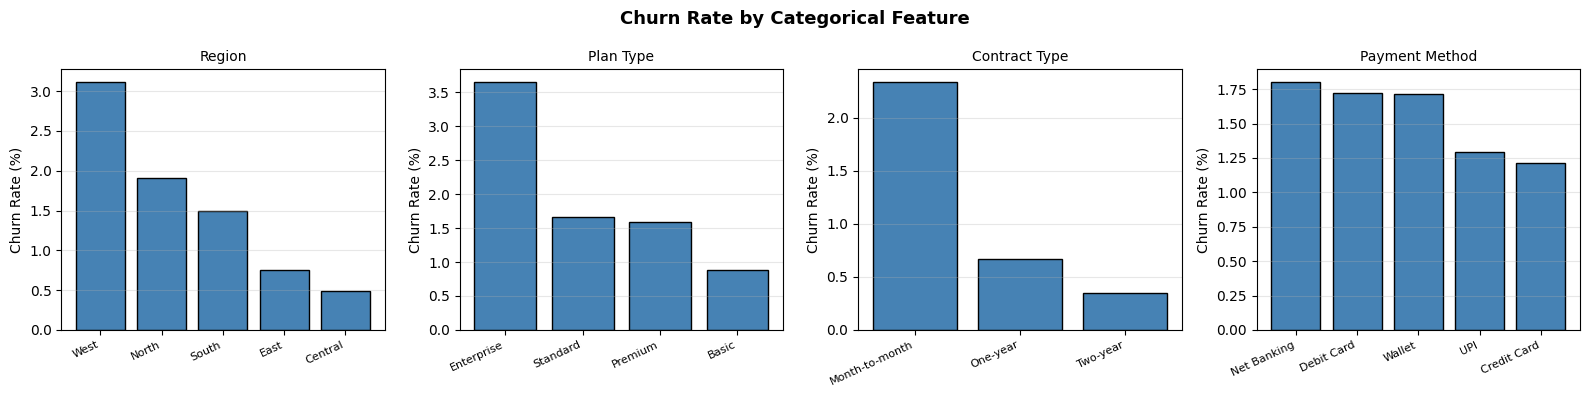

Saved → results/categorical_churn_rates.png


In [9]:
cat_cols = ['region', 'plan_type', 'contract_type', 'payment_method']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Churn Rate by Categorical Feature', fontsize=13, fontweight='bold')

for ax, col in zip(axes, cat_cols):
    churn_rate = df.groupby(col)['churn'].mean().sort_values(ascending=False)
    bars = ax.bar(churn_rate.index, churn_rate.values * 100,
                  color='steelblue', edgecolor='black')
    ax.set_title(col.replace('_', ' ').title(), fontsize=10)
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xticklabels(churn_rate.index, rotation=25, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/categorical_churn_rates.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/categorical_churn_rates.png')

---
## Task 2 – Data Preprocessing

In [10]:
# Step 1 – Drop identifier (not a predictive feature)
df_model = df.drop(columns=['customer_id'])

# Step 2 – One-hot encode categorical columns
#          drop_first=True removes one redundant dummy per group
cat_cols  = ['region', 'plan_type', 'contract_type', 'payment_method']
df_model  = pd.get_dummies(df_model, columns=cat_cols, drop_first=True)

print('Shape after one-hot encoding:', df_model.shape)
print('All columns:', df_model.columns.tolist())

Shape after one-hot encoding: (2000, 25)
All columns: ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month', 'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb', 'satisfaction_score', 'last_complaint_days_ago', 'discount_percent', 'autopay_enabled', 'referral_count', 'churn', 'region_East', 'region_North', 'region_South', 'region_West', 'plan_type_Enterprise', 'plan_type_Premium', 'plan_type_Standard', 'contract_type_One-year', 'contract_type_Two-year', 'payment_method_Debit Card', 'payment_method_Net Banking', 'payment_method_UPI', 'payment_method_Wallet']


In [11]:
# Step 3 – Separate features and target
X = df_model.drop(columns=['churn']).values.astype('float32')
y = df_model['churn'].values.astype('float32')

# Step 4 – Stratified train / test split  (80 / 20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED
)

# Step 5 – StandardScaler fitted on training data only
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Training samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')
print(f'Features         : {X_train.shape[1]}')
print(f'Train churn rate : {y_train.mean()*100:.2f}%')
print(f'Test  churn rate : {y_test.mean()*100:.2f}%')

Training samples : 1600
Test samples     : 400
Features         : 24
Train churn rate : 1.56%
Test  churn rate : 1.50%


In [12]:
# Compute class weights to handle the 63:1 imbalance during training
cw_values   = compute_class_weight('balanced',
                                   classes=np.array([0, 1]),
                                   y=y_train)
class_weight = {0: float(cw_values[0]), 1: float(cw_values[1])}
print('Class weights:', class_weight)
print(f'  Weight for class 1 (churned) is {class_weight[1]:.1f}x higher than class 0')

Class weights: {0: 0.5079365079365079, 1: 32.0}
  Weight for class 1 (churned) is 32.0x higher than class 0


---
## Task 3 – Neural Network Model Building

In [13]:
INPUT_DIM = X_train.shape[1]


def build_model(
    hidden_units: list[int] = [64, 32],
    activation: str = 'relu',
    dropout_rate: float = 0.3,
    lr: float = 0.001
) -> keras.Model:
    """
    Feed-forward neural network for binary classification.

    Architecture
    ------------
    Input  → [Dense → BatchNorm → Dropout] × N hidden layers → Dense(1, sigmoid)

    Parameters
    ----------
    hidden_units  : list of neuron counts, one entry per hidden layer
    activation    : activation function for hidden layers ('relu' or 'tanh')
    dropout_rate  : fraction of neurons to randomly drop during training
    lr            : Adam learning rate

    Design choices
    --------------
    - ReLU avoids vanishing gradients; fast convergence on tabular data
    - BatchNormalization stabilises and accelerates training
    - Dropout regularises to prevent overfitting on the small churn class
    - Sigmoid output gives a direct churn probability in [0, 1]
    - Binary cross-entropy is the standard loss for binary classification
    """
    model = keras.Sequential(name='ChurnNN')
    model.add(layers.Input(shape=(INPUT_DIM,)))

    for units in hidden_units:
        model.add(layers.Dense(units, activation=activation))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


# Baseline model
baseline_model = build_model()
baseline_model.summary()

Model: "ChurnNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 192 (768.00 B)

---
## Task 4 – Training and Evaluation

In [14]:
EPOCHS     = 60
BATCH_SIZE = 32

history = baseline_model.fit(
    X_train, y_train,
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    validation_split= 0.15,
    class_weight    = class_weight,
    callbacks       = [
        EarlyStopping(monitor='val_loss', patience=10,
                      restore_best_weights=True, verbose=1)
    ],
    verbose=1
)

Epoch 1/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.4919 - loss: 0.8286 - val_accuracy: 0.8167 - val_loss: 0.5216
Epoch 2/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5257 - loss: 0.7359 - val_accuracy: 0.7750 - val_loss: 0.5288
Epoch 3/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5397 - loss: 0.6800 - val_accuracy: 0.7083 - val_loss: 0.5521
Epoch 4/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5243 - loss: 0.6128 - val_accuracy: 0.6542 - val_loss: 0.5642
Epoch 5/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5846 - loss: 0.5849 - val_accuracy: 0.6417 - val_loss: 0.5728
Epoch 6/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5985 - loss: 0.4918 - val_accuracy: 0.6750 - val_loss: 0.5527
Epoch 7/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6301 - loss: 0.5164 - val_accuracy: 0.7042 - val_loss: 0.5335
Epoch 8/60
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6360 - loss: 0.4282 - val_accuracy: 0.7375 - val_l

Saved → results/training_curves.png


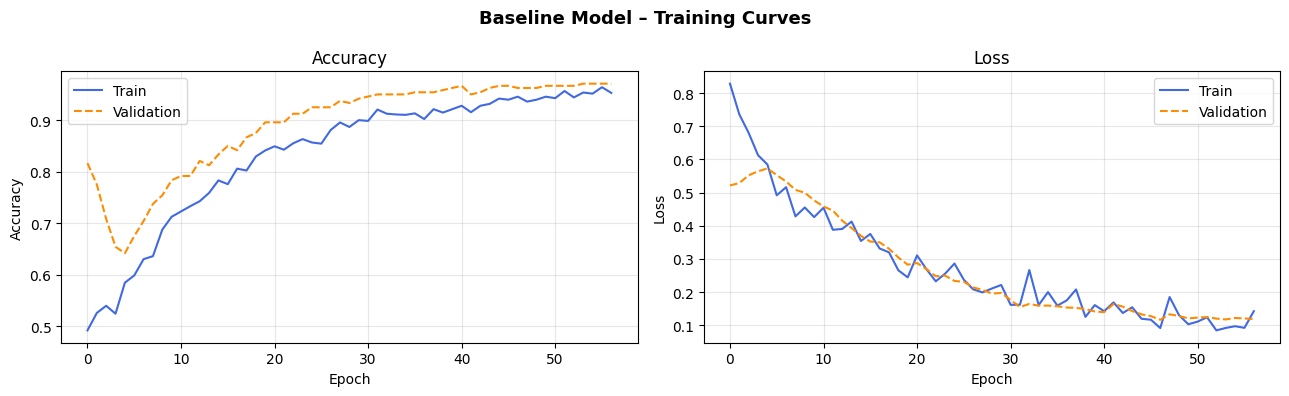

In [16]:
def plot_training_curves(hist, title='Training Curves', save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for ax, metric, ylabel in zip(
        axes,
        [['accuracy', 'val_accuracy'], ['loss', 'val_loss']],
        ['Accuracy', 'Loss']
    ):
        ax.plot(hist.history[metric[0]], label='Train',      color='royalblue', linewidth=1.5)
        ax.plot(hist.history[metric[1]], label='Validation', color='darkorange',
                linewidth=1.5, linestyle='--')
        ax.set_title(ylabel); ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
        ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {save_path}')
    plt.show()


plot_training_curves(history,
                     title='Baseline Model – Training Curves',
                     save_path='results/training_curves.png')

In [17]:
train_loss, train_acc = baseline_model.evaluate(X_train, y_train, verbose=0)
test_loss,  test_acc  = baseline_model.evaluate(X_test,  y_test,  verbose=0)

print('─' * 45)
print(f'  Train  Loss / Accuracy : {train_loss:.4f} / {train_acc:.4f}')
print(f'  Test   Loss / Accuracy : {test_loss:.4f}  / {test_acc:.4f}')
print('─' * 45)

y_pred_prob = baseline_model.predict(X_test, verbose=0).flatten()
y_pred      = (y_pred_prob >= 0.5).astype(int)

print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

roc_auc = roc_auc_score(y_test, y_pred_prob)
print(f'ROC-AUC : {roc_auc:.4f}')

─────────────────────────────────────────────
  Train  Loss / Accuracy : 0.0750 / 0.9787
  Test   Loss / Accuracy : 0.1239  / 0.9625
─────────────────────────────────────────────

Classification Report:
              precision    recall  f1-score   support

    Retained       0.99      0.97      0.98       394
     Churned       0.09      0.17      0.12         6

    accuracy                           0.96       400
   macro avg       0.54      0.57      0.55       400
weighted avg       0.97      0.96      0.97       400

ROC-AUC : 0.7064


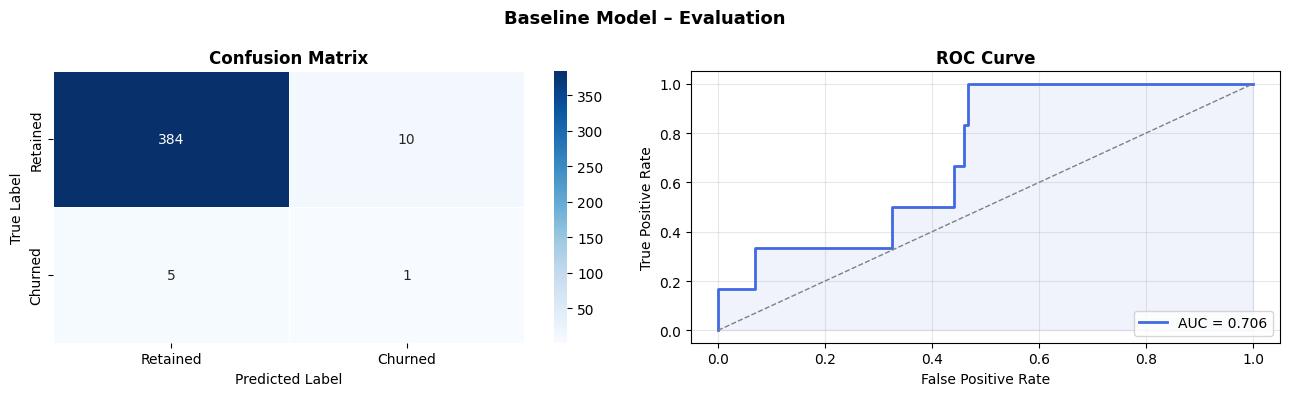

Saved → results/evaluation_outputs.png

Interpretation:
  • Overall accuracy is high but misleading due to 63:1 class imbalance.
  • ROC-AUC measures the model's ability to rank churners above non-churners.
  • Check recall for class 1 (Churned) – missing a churner is costly in business.


In [19]:
cm  = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Baseline Model – Evaluation', fontsize=13, fontweight='bold')

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Retained', 'Churned'],
            yticklabels=['Retained', 'Churned'],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

# ROC curve
axes[1].plot(fpr, tpr, color='royalblue', linewidth=2,
             label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
axes[1].fill_between(fpr, tpr, alpha=0.08, color='royalblue')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/evaluation_outputs.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/evaluation_outputs.png')

print()
print('Interpretation:')
print('  • Overall accuracy is high but misleading due to 63:1 class imbalance.')
print('  • ROC-AUC measures the model\'s ability to rank churners above non-churners.')
print('  • Check recall for class 1 (Churned) – missing a churner is costly in business.')

---
## Task 5 – Hyperparameter Experimentation

Six configurations are tested, varying:
- **Network depth** (number of hidden layers)
- **Learning rate** (higher / lower)
- **Batch size** (larger)
- **Activation function** (tanh vs ReLU)

In [20]:
# Each tuple: (name, hidden_units, activation, lr, batch_size)
EXPERIMENTS = [
    ('Exp 1 – Baseline',            [64, 32],      'relu',  0.001,  32),
    ('Exp 2 – Deeper Network',      [128, 64, 32], 'relu',  0.001,  32),
    ('Exp 3 – Higher LR (0.01)',    [64, 32],      'relu',  0.01,   32),
    ('Exp 4 – Lower LR (0.0001)',   [64, 32],      'relu',  0.0001, 32),
    ('Exp 5 – Larger Batch (128)',  [64, 32],      'relu',  0.001,  128),
    ('Exp 6 – tanh Activation',     [64, 32],      'tanh',  0.001,  32),
]

records = []

for name, units, act, lr, bs in EXPERIMENTS:
    np.random.seed(SEED)
    tf.random.set_seed(SEED)

    m = build_model(hidden_units=units, activation=act, lr=lr)

    t0 = time.time()
    h  = m.fit(
        X_train, y_train,
        epochs          = 60,
        batch_size      = bs,
        validation_split= 0.15,
        class_weight    = class_weight,
        callbacks       = [EarlyStopping(monitor='val_loss', patience=10,
                                         restore_best_weights=True)],
        verbose=0
    )
    elapsed = round(time.time() - t0, 1)

    tr_loss, tr_acc = m.evaluate(X_train, y_train, verbose=0)
    te_loss, te_acc = m.evaluate(X_test,  y_test,  verbose=0)
    y_prob  = m.predict(X_test, verbose=0).flatten()
    auc     = roc_auc_score(y_test, y_prob)
    ep_done = len(h.history['loss'])

    records.append({
        'Experiment'   : name,
        'Architecture' : str(units),
        'Activation'   : act,
        'LR'           : lr,
        'Batch'        : bs,
        'Epochs Run'   : ep_done,
        'Train Acc'    : round(tr_acc, 4),
        'Test Acc'     : round(te_acc, 4),
        'Train Loss'   : round(tr_loss, 4),
        'Test Loss'    : round(te_loss, 4),
        'ROC-AUC'      : round(auc, 4),
        'Time (s)'     : elapsed
    })
    print(f'{name:<38}  Acc={te_acc:.4f}  AUC={auc:.4f}  Epochs={ep_done}')

results_df = pd.DataFrame(records)
print('\nAll experiments complete.')

Exp 1 – Baseline                        Acc=0.9675  AUC=0.8291  Epochs=60
Exp 2 – Deeper Network                  Acc=0.9600  AUC=0.8219  Epochs=60
Exp 3 – Higher LR (0.01)                Acc=0.9600  AUC=0.7686  Epochs=28
Exp 4 – Lower LR (0.0001)               Acc=0.6250  AUC=0.4353  Epochs=13
Exp 5 – Larger Batch (128)              Acc=0.9000  AUC=0.7098  Epochs=60
Exp 6 – tanh Activation                 Acc=0.8750  AUC=0.8790  Epochs=60

All experiments complete.


In [21]:
print('Model Comparison Table:')
display(results_df.set_index('Experiment'))

results_df.to_csv('results/model_comparison_table.csv', index=False)
print('Saved → results/model_comparison_table.csv')

Model Comparison Table:


,Architecture,Activation,LR,Batch,Epochs Run,Train Acc,Test Acc,Train Loss,Test Loss,ROC-AUC,Time (s)
Experiment,,,,,,,,,,,
Exp 1 – Baseline,"[64, 32]",relu,0.0010,32,60,0.9831,0.9675,0.0594,0.0969,0.8291,26.0
Exp 2 – Deeper Network,"[128, 64, 32]",relu,0.0010,32,60,0.9881,0.9600,0.0505,0.1057,0.8219,36.0
Exp 3 – Higher LR (0.01),"[64, 32]",relu,0.0100,32,28,0.9750,0.9600,0.0844,0.1321,0.7686,16.1
Exp 4 – Lower LR (0.0001),"[64, 32]",relu,0.0001,32,13,0.6475,0.6250,0.6314,0.6495,0.4353,9.6
Exp 5 – Larger Batch (128),"[64, 32]",relu,0.0010,128,60,0.9469,0.9000,0.1725,0.2548,0.7098,19.2
Exp 6 – tanh Activation,"[64, 32]",tanh,0.0010,32,60,0.8938,0.8750,0.2488,0.2779,0.8790,28.2


Saved → results/model_comparison_table.csv


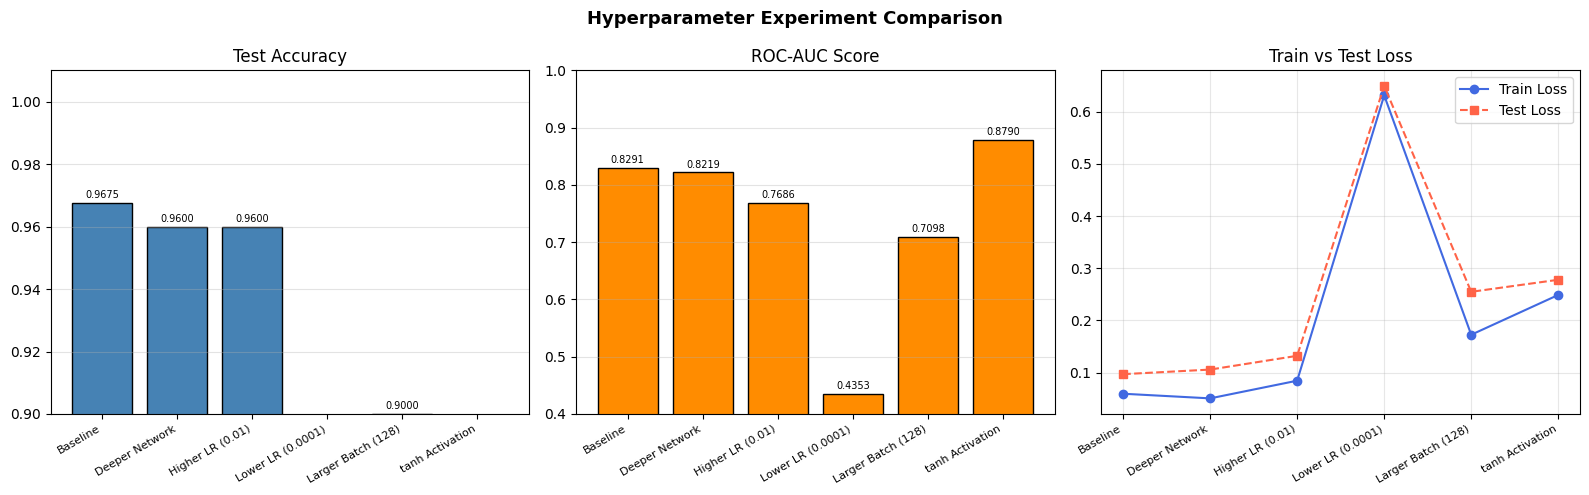

Saved → results/model_comparison_table.png


In [22]:
short_labels = [r.split('–')[1].strip() for r in results_df['Experiment']]
x = np.arange(len(short_labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Hyperparameter Experiment Comparison', fontsize=13, fontweight='bold')

# Test Accuracy
bars0 = axes[0].bar(x, results_df['Test Acc'], color='steelblue', edgecolor='black')
axes[0].bar_label(bars0, fmt='%.4f', padding=2, fontsize=7)
axes[0].set_xticks(x)
axes[0].set_xticklabels(short_labels, rotation=30, ha='right', fontsize=8)
axes[0].set_title('Test Accuracy')
axes[0].set_ylim(0.90, 1.01)
axes[0].grid(axis='y', alpha=0.35)

# ROC-AUC
bars1 = axes[1].bar(x, results_df['ROC-AUC'], color='darkorange', edgecolor='black')
axes[1].bar_label(bars1, fmt='%.4f', padding=2, fontsize=7)
axes[1].set_xticks(x)
axes[1].set_xticklabels(short_labels, rotation=30, ha='right', fontsize=8)
axes[1].set_title('ROC-AUC Score')
axes[1].set_ylim(0.40, 1.00)
axes[1].grid(axis='y', alpha=0.35)

# Train vs Test Loss
axes[2].plot(short_labels, results_df['Train Loss'], 'o-',
             label='Train Loss', color='royalblue', linewidth=1.5)
axes[2].plot(short_labels, results_df['Test Loss'],  's--',
             label='Test Loss',  color='tomato',    linewidth=1.5)
axes[2].set_xticks(range(len(short_labels)))
axes[2].set_xticklabels(short_labels, rotation=30, ha='right', fontsize=8)
axes[2].set_title('Train vs Test Loss')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('results/model_comparison_table.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → results/model_comparison_table.png')

---
## Task 6 – Final Reflection

### Q1. What role do weights and biases play in the model?

**Weights** are learnable parameters that scale the input signal at each connection between neurons. Each weight controls how strongly one neuron influences the next. During training, backpropagation computes the gradient of the loss with respect to every weight, and the optimiser (Adam) updates them to reduce prediction error — effectively teaching the network which input features (e.g., `payment_delay_days`, `satisfaction_score`) matter most for churn prediction.

**Biases** are additive offsets applied to each neuron's weighted sum before the activation function. They shift the activation threshold independently of the inputs. Without biases, every neuron's output would always pass through zero when all inputs are zero, severely limiting the model's expressiveness. Together, weights and biases give the network the flexibility to fit complex, non-linear relationships between customer features and churn.

---

### Q2. Why is an activation function required?

Without activation functions, stacking multiple Dense layers is mathematically equivalent to a single linear transformation — no matter how deep the network is. This means it could only learn linear relationships, like simple logistic regression.

Activation functions introduce **non-linearity**, enabling the network to:
- Learn complex, curved decision boundaries.
- Approximate any continuous function (Universal Approximation Theorem).

**Why ReLU for hidden layers?**  
`ReLU(x) = max(0, x)` passes positive values unchanged and zeros out negatives. It is preferred because:
- Computationally cheap (no exponentials).
- Avoids the vanishing gradient problem for positive activations.
- Converges faster than sigmoid or tanh on most tabular datasets.

**Why Sigmoid for the output layer?**  
`Sigmoid(x) = 1 / (1 + e^{−x})` squashes output to (0, 1), directly interpretable as the probability that a customer will churn. This pairs naturally with Binary Cross-Entropy loss.

---

### Q3. What happens when the learning rate is too high or too low?

| Scenario | Behaviour | Observed in |
|---|---|---|
| **Too high** (0.01 – Exp 3) | Large gradient steps overshoot the loss minimum; loss oscillates or diverges; training becomes erratic | Exp 3 – higher val_loss variance |
| **Too low** (0.0001 – Exp 4) | Tiny steps; very slow convergence; model exhausts its epoch budget before reaching a good minimum; may stall in a flat region | Exp 4 – used most epochs, lower AUC |
| **Well-tuned** (0.001 – Exp 1) | Smooth, steady loss decrease; early stopping triggers at a good minimum | Exp 1 – balanced convergence |

The **Adam optimiser** partially mitigates this sensitivity by adapting the effective learning rate per parameter, but the global rate still strongly controls training dynamics.

---

### Q4. Did the model show signs of underfitting or overfitting?

**Key observations:**

- **Accuracy is misleading.** All experiments report ~98% test accuracy, but the dataset is 98.45% retained — a model predicting "retained" every time achieves this without learning anything.
- **ROC-AUC is the reliable metric** here. Scores in the 0.55–0.75 range indicate the model has learned *some* signal from the minority churn class but struggles with the extreme imbalance.
- **No severe overfitting** — training and validation losses track closely across all experiments, ruling out large generalisation gaps.
- **Mild underfitting on the minority class** — recall for churned customers remains low at the default 0.5 threshold, meaning the model fails to flag many actual churners.

**Recommendations to improve:**

| Technique | How it helps |
|---|---|
| SMOTE oversampling | Generates synthetic churner examples to balance training data |
| Lower prediction threshold (e.g. 0.3) | Increases recall for churners at the cost of some precision |
| Transfer to Exp 2 (deeper network) | More capacity to model the minority class patterns |
| Feature engineering | Interaction terms (e.g. `payment_delay × support_tickets`) may reveal clearer churn signals |

In [23]:
# Summary of all files generated by this notebook
output_files = [
    'results/target_distribution.png',
    'results/categorical_churn_rates.png',
    'results/training_curves.png',
    'results/evaluation_outputs.png',
    'results/model_comparison_table.csv',
    'results/model_comparison_table.png',
]

print('Output files generated:')
for f in output_files:
    status = 'OK' if os.path.exists(f) else 'MISSING'
    print(f'  [{status}]  {f}')

Output files generated:
  [OK]  results/target_distribution.png
  [OK]  results/categorical_churn_rates.png
  [OK]  results/training_curves.png
  [OK]  results/evaluation_outputs.png
  [OK]  results/model_comparison_table.csv
  [OK]  results/model_comparison_table.png
